<a href="https://colab.research.google.com/github/yenipp/TA-Klasifikasi-Tingkat-Risiko-Stroke/blob/main/TAYeni.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== 5 BARIS PERTAMA DATASET MENTAH ===
                Timestamp Nama / Inisial  Usia (Tahun) Jenis Kelamin  \
0 2026-07-07 12:35:58.123           yaya            50     Perempuan   
1 2026-07-07 13:43:44.905           eria            30     Perempuan   
2 2026-07-12 08:53:54.366          Laila            25     Perempuan   
3 2026-07-12 08:55:16.174           Nana            25     Perempuan   
4 2026-07-12 08:56:56.852          Parti            49     Perempuan   

  Tipe Lingkungan Tempat Tinggal       Status Pernikahan  \
0                       Pedesaan  Sudah / Pernah Menikah   
1                      Perkotaan  Sudah / Pernah Menikah   
2                      Perkotaan    Belum Pernah Menikah   
3                      Perkotaan    Belum Pernah Menikah   
4                      Perkotaan  Sudah / Pernah Menikah   

                           Tipe Pekerj

,Kategori Risiko,Frekuensi Responden,Persentase (%)
0,0 (Low Risk),92,45.77%
1,1 (Caution),32,15.92%
2,2 (High Risk),77,38.31%
3,Total,201,100%



=== TABEL REKAPITULASI 9 INDIKATOR KESEHATAN ===


,Indikator Kesehatan & Gaya Hidup,Normal / Sehat (0),Sedang / Tdk Tahu (1),Risiko Tinggi (2),Modus,Median,Mean
0,1. Tekanan Darah (Hipertensi),112 (55.7%),29 (14.4%),60 (29.9%),0,0.0,0.74
1,2. Kadar Gula Darah (Diabetes),103 (51.2%),62 (30.8%),36 (17.9%),0,0.0,0.67
2,3. Kadar Kolesterol Total,84 (41.8%),70 (34.8%),47 (23.4%),0,1.0,0.82
3,4. Riwayat Penyakit Jantung,112 (55.7%),52 (25.9%),37 (18.4%),0,0.0,0.63
4,5. Kebiasaan Merokok,108 (53.7%),37 (18.4%),56 (27.9%),0,0.0,0.74
5,6. Berat Badan (BMI),103 (51.2%),70 (34.8%),28 (13.9%),0,0.0,0.63
6,7. Kebiasaan Olahraga,59 (29.4%),80 (39.8%),62 (30.8%),1,1.0,1.01
7,8. Riwayat Stroke Keluarga,90 (44.8%),48 (23.9%),63 (31.3%),0,1.0,0.87
8,9. Riwayat Stroke Pribadi,173 (86.1%),0 (0.0%),28 (13.9%),0,0.0,0.28


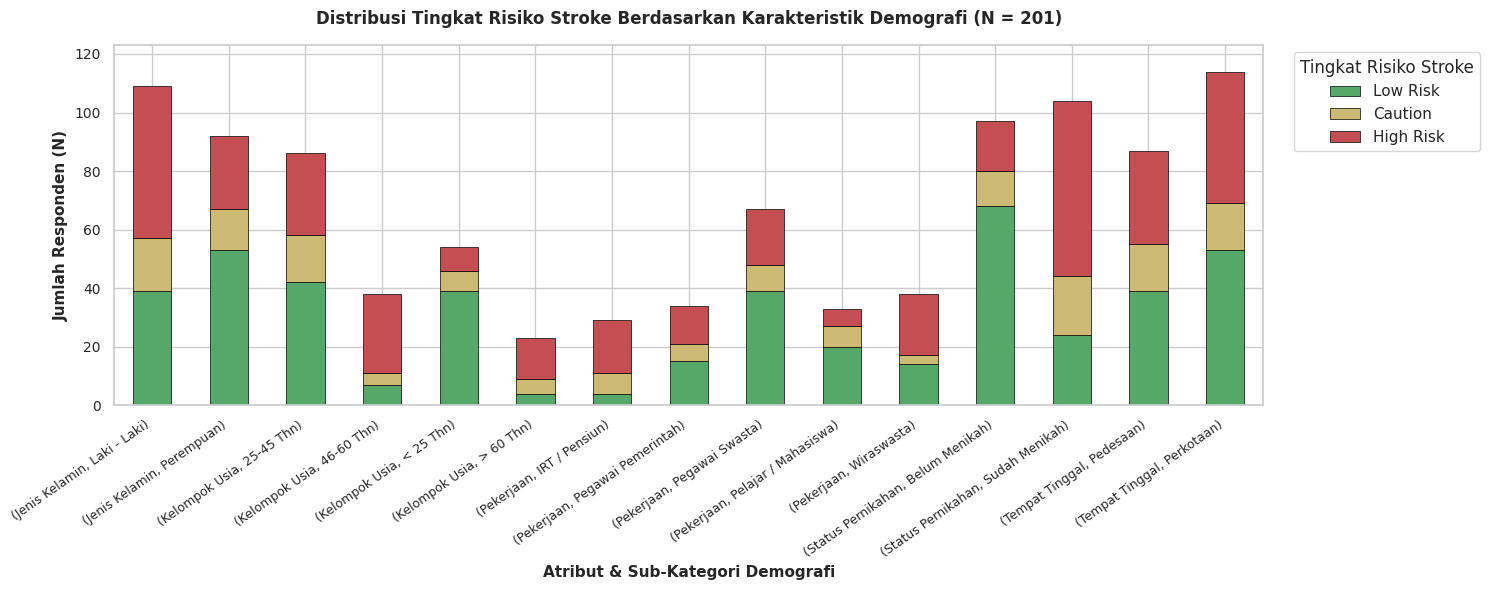

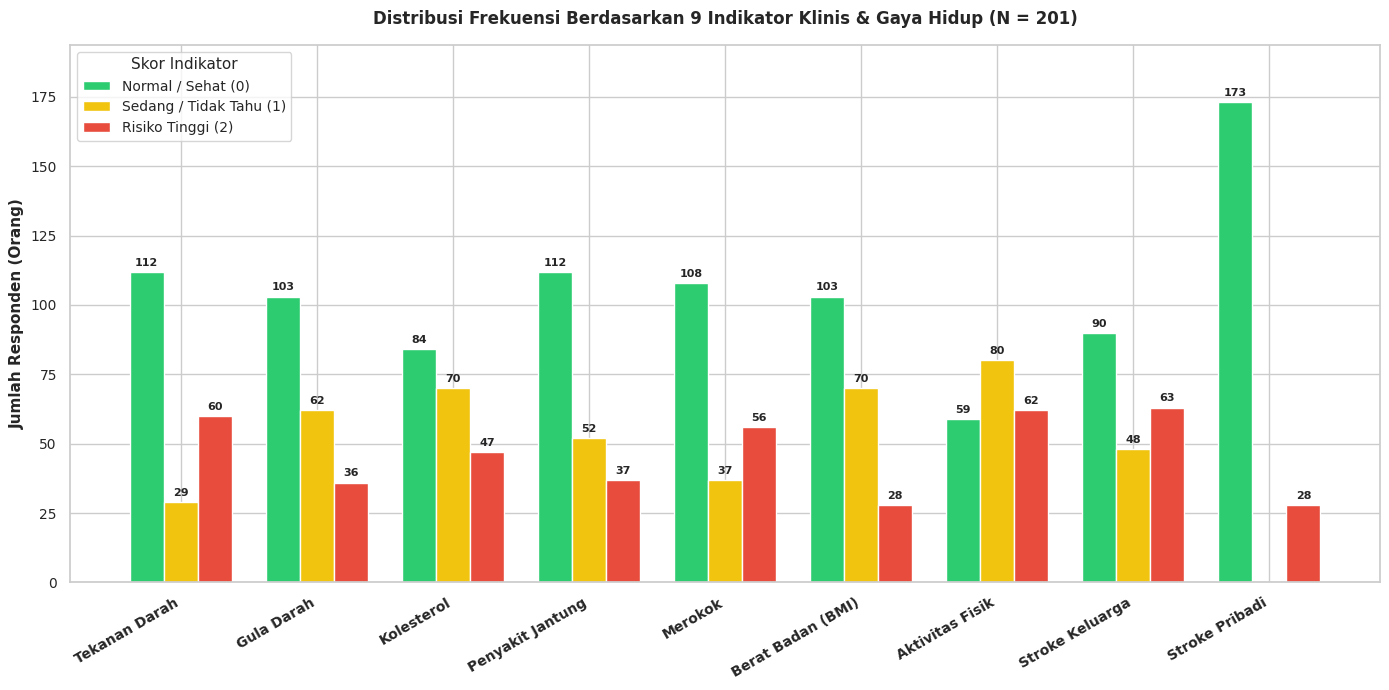

In [9]:
# ==============================================================================
# PROYEK SKRIPSI: TAHAP EXPLORATORY DATA ANALYSIS (EDA) & DATA SCRUBBING
# ==============================================================================

# 1. IMPORT PUSTAKA UTAMA
from google.colab import drive
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ==============================================================================
# 2. MOUNT GOOGLE DRIVE & BACA DATA KUESIONER
# ==============================================================================
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/TA/Hasil Kuesioner.xlsx'
df_raw = pd.read_excel(file_path)

total_n = len(df_raw)
print('=== 5 BARIS PERTAMA DATASET MENTAH ===')
print(df_raw.head())

print('\n=== INFORMASI KOLOM DATASET ===')
print(df_raw.info())
print(f'Total responden (N): {total_n}\n')


# ==============================================================================
# 3. ANALISIS STATISTIK DESKRIPTIF & DISTRIBUSI FREKUENSI AWAL
# ==============================================================================
# Statistik Deskriptif Variabel Numerik (Usia [2], Tinggi Badan [7], Berat Badan [8])
numerical_indices = [2, 7, 8]
num_cols = [df_raw.columns[i] for i in numerical_indices]

desc_num = df_raw[num_cols].describe().T[['mean', 'std', 'min', '50%', 'max']]
desc_num.columns = [
    'Mean (Rata-rata)',
    'Std. Deviasi',
    'Minimum',
    'Median (Q2)',
    'Maksimum',
]

print('=' * 70)
print('TABEL 1: STATISTIK DESKRIPTIF VARIABEL NUMERIK')
print('=' * 70)
print(desc_num.round(2).to_string())
print('\n' + '=' * 70 + '\n')

# Pembuatan Kelompok Usia
bins = [0, 25, 45, 60, 100]
labels = ['< 25 Tahun', '25 - 45 Tahun', '46 - 60 Tahun', '> 60 Tahun']
df_raw['Kelompok Usia'] = pd.cut(
    df_raw['Usia (Tahun)'], bins=bins, labels=labels, right=True
)

categorical_indices = [3, 4, 5, 6, 9, 10, 11, 12, 13, 14, 15, 16]
cat_cols = [df_raw.columns[i] for i in categorical_indices]

print('=' * 70)
print('TABEL 2: DISTRIBUSI FREKUENSI DAN PERSENTASE KATEGORIKAL')
print('=' * 70)

print('\nVariabel: Kelompok Usia')
usia_freq = df_raw['Kelompok Usia'].value_counts().loc[labels]
usia_percent = (
    df_raw['Kelompok Usia'].value_counts(normalize=True).loc[labels] * 100
).round(2)
dist_usia = pd.DataFrame(
    {'Frekuensi (N)': usia_freq, 'Persentase (%)': usia_percent}
)
print(dist_usia.to_string())
print('-' * 50)

for col in cat_cols:
  print(f'\nVariabel: {col}')
  freq = df_raw[col].value_counts()
  percent = (df_raw[col].value_counts(normalize=True) * 100).round(2)
  dist_df = pd.DataFrame({'Frekuensi (N)': freq, 'Persentase (%)': percent})
  print(dist_df.to_string())
  print('-' * 50)

print(f'\nTotal responden (N): {len(df_raw)}\n')


# ==============================================================================
# 4. PENGECEKAN MISSING VALUES & DATA DUPLIKAT (SCRUBBING AWAL)
# ==============================================================================
total_responden = len(df_raw)
total_missing = df_raw.isnull().sum().sum()
total_duplicate = df_raw.duplicated().sum()

print('=' * 70)
print('LAPORAN PENGECEKAN KUALITAS DATA MENTAH')
print('=' * 70)
print(f'Total Responden       : {total_responden} sampel')
print(f'Jumlah Missing Values : {total_missing}')
print(f'Jumlah Data Duplikat  : {total_duplicate}')
print(f'Total Sampel Valid    : {total_responden} baris\n')


# ==============================================================================
# 5. PREPROCESSING & DATA SCRUBBING (ENCODING & ALOKASI RISIKO)
# ==============================================================================
df_scrubbed = pd.DataFrame()
df_scrubbed['Tinggi_Badan_cm'] = df_raw['Tinggi Badan (cm)']
df_scrubbed['Berat_Badan_kg'] = df_raw['Berat Badan (kg)']

# Hitung Nilai BMI Kontinu
tb_m = df_scrubbed['Tinggi_Badan_cm'] / 100.0
df_scrubbed['BMI_Nilai'] = (df_scrubbed['Berat_Badan_kg'] / (tb_m ** 2)).round(
    2
)


# Encoding BMI (Standar Asia-Pasifik)
def encode_bmi(row):
  bmi = row['BMI_Nilai']
  if bmi < 23.0:
    return 0  # Normal / Low Risk
  elif 23.0 <= bmi <= 27.5:
    return 1  # Overweight / Caution
  else:
    return 2  # Obese / High Risk


df_scrubbed['BMI_Encoded'] = df_scrubbed.apply(encode_bmi, axis=1)

# Kamus Pemetaan Ordinal Kuesioner
pemetaan_kuesioner = {
    'Tekanan Darah Tinggi (Hipertensi)': {
        'Tidak (<120/<80)': 0,
        'Tidak Tahu': 1,
        'Ya (130/≥80)': 2,
    },
    'Penyakit Jantung atau gejala gangguan jantung': {
        'Tidak': 0,
        'Tidak Tahu': 1,
        'Ya': 2,
    },
    'Kadar Gula Darah (Diabetes)': {'Tidak': 0, 'Tidak Tahu': 1, 'Ya': 2},
    'Kadar Kolesterol': {'Tidak (<200)': 0, 'Tidak Tahu': 1, 'Ya (≥240)': 2},
    'Aktivitas Fisik / Olahraga': {
        '3-4 kali seminggu olahraga': 0,
        '1-2 kali seminggu olahraga': 1,
        'Ya/Jarang Olahraga': 2,
    },
    'Bagaimana status merokok Anda saat ini?': {
        'Tidak Pernah Merokok': 0,
        'Pernah Merokok (Mantan Perokok)': 1,
        'Aktif Merokok': 2,
    },
    (
        'Apakah ada anggota keluarga inti Anda (Orang tua, Saudara Kandung, atau'
        ' Kakek/Nenek) yang memiliki riwayat pernah mengalami Stroke?'
    ): {'Tidak': 0, 'Tidak Tahu': 1, 'Ya': 2},
    (
        'Apakah Anda sendiri pernah secara resmi didiagnosis mengalami stroke'
        ' (termasuk stroke ringan) atau pernah mendadak mengalami gejala'
        ' klinis berikut?'
    ): {'Tidak': 0, 'Ya': 2},
}

for col, mapping in pemetaan_kuesioner.items():
  series_clean = df_raw[col].astype(str).str.strip()
  new_col_name = f'{col}_Encoded'
  df_scrubbed[new_col_name] = series_clean.map(mapping).fillna(0).astype(int)

# 9 Indikator Utama
col_hipertensi = 'Tekanan Darah Tinggi (Hipertensi)_Encoded'
col_diabetes = 'Kadar Gula Darah (Diabetes)_Encoded'
col_kolesterol = 'Kadar Kolesterol_Encoded'
col_jantung = 'Penyakit Jantung atau gejala gangguan jantung_Encoded'
col_merokok = 'Bagaimana status merokok Anda saat ini?_Encoded'
col_olahraga = 'Aktivitas Fisik / Olahraga_Encoded'
col_keluarga = (
    'Apakah ada anggota keluarga inti Anda (Orang tua, Saudara Kandung, atau'
    ' Kakek/Nenek) yang memiliki riwayat pernah mengalami Stroke?_Encoded'
)
col_pribadi = (
    'Apakah Anda sendiri pernah secara resmi didiagnosis mengalami stroke'
    ' (termasuk stroke ringan) atau pernah mendadak mengalami gejala'
    ' klinis berikut?_Encoded'
)

kolom_9_indikator = [
    col_hipertensi,
    col_diabetes,
    col_kolesterol,
    col_jantung,
    col_merokok,
    'BMI_Encoded',
    col_olahraga,
    col_keluarga,
    col_pribadi,
]

df_scrubbed['Poin_High_Risk'] = (df_scrubbed[kolom_9_indikator] == 2).sum(axis=1)
df_scrubbed['Poin_Caution'] = (df_scrubbed[kolom_9_indikator] == 1).sum(axis=1)


def alokasi_kategori_risiko(row):
  stroke_pribadi = row[col_pribadi]
  poin_hr = row['Poin_High_Risk']
  poin_c = row['Poin_Caution']
  if stroke_pribadi == 2 or poin_hr >= 3:
    return 2
  elif 4 <= poin_c <= 6:
    return 1
  else:
    return 0


df_scrubbed['Kategori_Risiko'] = df_scrubbed.apply(
    alokasi_kategori_risiko, axis=1
)
df_scrubbed.to_excel('/content/drive/MyDrive/df_scrubbed_hasil.xlsx', index=False)

f_0 = (df_scrubbed['Kategori_Risiko'] == 0).sum()
f_1 = (df_scrubbed['Kategori_Risiko'] == 1).sum()
f_2 = (df_scrubbed['Kategori_Risiko'] == 2).sum()
total = len(df_scrubbed)

mapping_risiko = {0: 'Low Risk', 1: 'Caution', 2: 'High Risk'}
df_scrubbed['Label_Risiko'] = df_scrubbed['Kategori_Risiko'].map(mapping_risiko)

df_scrubbed['Kelompok Usia'] = pd.cut(
    df_raw['Usia (Tahun)'],
    bins=[0, 25, 45, 60, 100],
    labels=['< 25 Thn', '25-45 Thn', '46-60 Thn', '> 60 Thn'],
)
df_scrubbed['Jenis Kelamin'] = df_raw['Jenis Kelamin']
df_scrubbed['Tempat Tinggal'] = df_raw['Tipe Lingkungan Tempat Tinggal']
df_scrubbed['Status Pernikahan'] = df_raw['Status Pernikahan']
df_scrubbed['Pekerjaan Utama'] = df_raw['Tipe Pekerjaan Utama']
df_scrubbed['Status Merokok'] = df_raw['Bagaimana status merokok Anda saat ini?']


# ==============================================================================
# 6. TABEL SILANG (CROSSTAB) DEMOGRAFI & REKAPITULASI RISIKO
# ==============================================================================
print('\n' + '=' * 60)
print('TABEL SILANG: KELOMPOK USIA VS KATEGORI RISIKO STROKE')
print('=' * 60)
ct_usia = pd.crosstab(
    df_scrubbed['Kelompok Usia'],
    df_scrubbed['Label_Risiko'],
    margins=True,
    margins_name='Total',
)
print(ct_usia.to_string())

print('\n' + '=' * 60)
print('TABEL SILANG: STATUS MEROKOK VS KATEGORI RISIKO STROKE')
print('=' * 60)
ct_merokok = pd.crosstab(
    df_scrubbed['Status Merokok'],
    df_scrubbed['Label_Risiko'],
    margins=True,
    margins_name='Total',
)
print(ct_merokok.to_string())

print('\n' + '=' * 60)
print('TABEL SILANG: JENIS KELAMIN VS KATEGORI RISIKO STROKE')
print('=' * 60)
ct_gender = pd.crosstab(
    df_scrubbed['Jenis Kelamin'],
    df_scrubbed['Label_Risiko'],
    margins=True,
    margins_name='Total',
)
print(ct_gender.to_string())

res_df = pd.DataFrame({
    'Kategori Risiko': ['0 (Low Risk)', '1 (Caution)', '2 (High Risk)', 'Total'],
    'Frekuensi Responden': [f_0, f_1, f_2, total],
    'Persentase (%)': [
        f'{(f_0/total)*100:.2f}%',
        f'{(f_1/total)*100:.2f}%',
        f'{(f_2/total)*100:.2f}%',
        '100%',
    ],
})
print('\n=== REKAPITULASI KLASIFIKASI RISIKO STROKE ===')
display(res_df)


# ==============================================================================
# 7. TABEL DESKRIPTIF 9 INDIKATOR KESEHATAN
# ==============================================================================
kolom_mapping = [
    ('Tekanan Darah Tinggi', '1. Tekanan Darah (Hipertensi)'),
    ('Kadar Gula Darah', '2. Kadar Gula Darah (Diabetes)'),
    ('Kadar Kolesterol', '3. Kadar Kolesterol Total'),
    ('Penyakit Jantung', '4. Riwayat Penyakit Jantung'),
    ('status merokok', '5. Kebiasaan Merokok'),
    ('BMI_Encoded', '6. Berat Badan (BMI)'),
    ('Aktivitas Fisik', '7. Kebiasaan Olahraga'),
    ('keluarga', '8. Riwayat Stroke Keluarga'),
    ('sendiri', '9. Riwayat Stroke Pribadi'),
]

rekap_data = []
for key, label_indikator in kolom_mapping:
  matched_cols = [
      c
      for c in df_scrubbed.columns
      if key.lower() in c.lower() and 'encoded' in c.lower()
  ]
  if not matched_cols:
    continue
  col_name = matched_cols[0]
  total_n = len(df_scrubbed[col_name])

  f_0 = (df_scrubbed[col_name] == 0).sum()
  f_1 = (df_scrubbed[col_name] == 1).sum()
  f_2 = (df_scrubbed[col_name] == 2).sum()

  p_0 = (f_0 / total_n) * 100
  p_1 = (f_1 / total_n) * 100
  p_2 = (f_2 / total_n) * 100

  modus_val = int(df_scrubbed[col_name].mode()[0])
  median_val = float(df_scrubbed[col_name].median())
  mean_val = float(df_scrubbed[col_name].mean())

  rekap_data.append({
      'Indikator Kesehatan & Gaya Hidup': label_indikator,
      'Normal / Sehat (0)': f'{f_0} ({p_0:.1f}%)',
      'Sedang / Tdk Tahu (1)': f'{f_1} ({p_1:.1f}%)',
      'Risiko Tinggi (2)': f'{f_2} ({p_2:.1f}%)',
      'Modus': modus_val,
      'Median': f'{median_val:.1f}',
      'Mean': f'{mean_val:.2f}',
  })

tabel_deskriptif = pd.DataFrame(rekap_data)
print('\n=== TABEL REKAPITULASI 9 INDIKATOR KESEHATAN ===')
display(tabel_deskriptif)


# ==============================================================================
# 8. VISUALISASI 1: STACKED BAR CHART DEMOGRAFI
# ==============================================================================
plot_rows = []
demographic_cols = [
    'Kelompok Usia',
    'Jenis Kelamin',
    'Tempat Tinggal',
    'Status Pernikahan',
    'Pekerjaan Utama',
]

for attr in demographic_cols:
  ct = pd.crosstab(df_scrubbed[attr], df_scrubbed['Label_Risiko'])
  for sub_cat in ct.index:
    for risiko in ['Low Risk', 'Caution', 'High Risk']:
      jumlah = ct.loc[sub_cat, risiko] if risiko in ct.columns else 0
      plot_rows.append({
          'Atribut_Utama': attr,
          'Sub_Kategori': str(sub_cat),
          'Tingkat_Risiko': risiko,
          'Jumlah': jumlah,
      })

df_single_plot = pd.DataFrame(plot_rows)

attr_mapping = {'Pekerjaan Utama': 'Pekerjaan'}
subcat_mapping = {
    'Tidak Bekerja / Ibu Rumah Tangga / Pensiunan': 'IRT / Pensiun',
    'Wiraswasta / Usaha Sendiri': 'Wiraswasta',
    'Belum Bekerja / Pelajar / Mahasiswa': 'Pelajar / Mahasiswa',
    'Sudah / Pernah Menikah': 'Sudah Menikah',
    'Belum Pernah Menikah': 'Belum Menikah',
}
df_single_plot['Atribut_Utama'] = df_single_plot['Atribut_Utama'].replace(
    attr_mapping
)
df_single_plot['Sub_Kategori'] = df_single_plot['Sub_Kategori'].replace(
    subcat_mapping
)

sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 10,
})

risk_palette = {
    'Low Risk': '#55a868',
    'Caution': '#ccb974',
    'High Risk': '#c44e52',
}
pivot_df = df_single_plot.pivot_table(
    index=['Atribut_Utama', 'Sub_Kategori'],
    columns='Tingkat_Risiko',
    values='Jumlah',
    fill_value=0,
)[['Low Risk', 'Caution', 'High Risk']]

fig, ax = plt.subplots(figsize=(15, 6))
pivot_df.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=[
        risk_palette['Low Risk'],
        risk_palette['Caution'],
        risk_palette['High Risk'],
    ],
    edgecolor='black',
    linewidth=0.5,
)
plt.title(
    'Distribusi Tingkat Risiko Stroke Berdasarkan Karakteristik Demografi (N ='
    ' 201)',
    pad=15,
    weight='bold',
    fontsize=12,
)
plt.xlabel('Atribut & Sub-Kategori Demografi', weight='bold')
plt.ylabel('Jumlah Responden (N)', weight='bold')
plt.xticks(rotation=35, ha='right')
plt.ylim(0, pivot_df.sum(axis=1).max() * 1.08)
plt.legend(
    title='Tingkat Risiko Stroke',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=True,
)
plt.tight_layout()
plt.savefig(
    'grafik_distribusi_risiko_demografi_rapi.png', dpi=300, bbox_inches='tight'
)
plt.show()


# ==============================================================================
# 9. VISUALISASI 2: GROUPED BAR CHART 9 INDIKATOR KLINIS & GAYA HIDUP
# ==============================================================================
indikator_cols_grafik = [
    'Tekanan Darah Tinggi (Hipertensi)_Encoded',
    'Kadar Gula Darah (Diabetes)_Encoded',
    'Kadar Kolesterol_Encoded',
    'Penyakit Jantung atau gejala gangguan jantung_Encoded',
    'Bagaimana status merokok Anda saat ini?_Encoded',
    'BMI_Encoded',
    'Aktivitas Fisik / Olahraga_Encoded',
    (
        'Apakah ada anggota keluarga inti Anda (Orang tua, Saudara Kandung, atau'
        ' Kakek/Nenek) yang memiliki riwayat pernah mengalami Stroke?_Encoded'
    ),
    (
        'Apakah Anda sendiri pernah secara resmi didiagnosis mengalami stroke'
        ' (termasuk stroke ringan) atau pernah mendadak mengalami gejala'
        ' klinis berikut?_Encoded'
    ),
]

nama_indikator_pendek = [
    'Tekanan Darah',
    'Gula Darah',
    'Kolesterol',
    'Penyakit Jantung',
    'Merokok',
    'Berat Badan (BMI)',
    'Aktivitas Fisik',
    'Stroke Keluarga',
    'Stroke Pribadi',
]

data_hitung = {
    'Indikator': nama_indikator_pendek,
    'Normal (0)': [],
    'Sedang (1)': [],
    'Tinggi (2)': [],
}

for col in indikator_cols_grafik:
  counts = df_scrubbed[col].value_counts().sort_index()
  data_hitung['Normal (0)'].append(counts.get(0, 0))
  data_hitung['Sedang (1)'].append(counts.get(1, 0))
  data_hitung['Tinggi (2)'].append(counts.get(2, 0))

df_chart_auto = pd.DataFrame(data_hitung)
x = np.arange(len(df_chart_auto['Indikator']))
width = 0.25
colors = ['#2ecc71', '#f1c40f', '#e74c3c']

fig, ax = plt.subplots(figsize=(14, 7))
rects1 = ax.bar(
    x - width,
    df_chart_auto['Normal (0)'],
    width,
    label='Normal / Sehat (0)',
    color=colors[0],
)
rects2 = ax.bar(
    x,
    df_chart_auto['Sedang (1)'],
    width,
    label='Sedang / Tidak Tahu (1)',
    color=colors[1],
)
rects3 = ax.bar(
    x + width,
    df_chart_auto['Tinggi (2)'],
    width,
    label='Risiko Tinggi (2)',
    color=colors[2],
)

ax.set_ylabel('Jumlah Responden (Orang)', fontsize=11, fontweight='bold')
ax.set_title(
    'Distribusi Frekuensi Berdasarkan 9 Indikator Klinis & Gaya Hidup (N = 201)',
    fontsize=12,
    fontweight='bold',
    pad=15,
)
ax.set_xticks(x)
ax.set_xticklabels(
    df_chart_auto['Indikator'],
    rotation=30,
    ha='right',
    fontsize=10,
    fontweight='bold',
)
ax.legend(title='Skor Indikator', fontsize=10, title_fontsize=11)


def autolabel(rects):
  for rect in rects:
    height = rect.get_height()
    if height > 0:
      ax.annotate(
          f'{height}',
          xy=(rect.get_x() + rect.get_width() / 2, height),
          xytext=(0, 3),
          textcoords='offset points',
          ha='center',
          va='bottom',
          fontsize=8,
          fontweight='bold',
      )


autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.ylim(
    0, df_chart_auto[['Normal (0)', 'Sedang (1)', 'Tinggi (2)']].values.max() * 1.12
)
plt.tight_layout()
plt.savefig('Grafik_2_Faktor_Kesehatan.png', dpi=300, bbox_inches='tight')
plt.show()

MODEL

In [10]:
# ==============================================================================
# PROYEK SKRIPSI: TAHAP PEMODELAN MACHINE LEARNING & HYPERPARAMETER TUNING
# ==============================================================================

# 1. IMPORT PUSTAKA UTAMA
from google.colab import drive
from imblearn.over_sampling import SMOTE
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.naive_bayes import CategoricalNB
from sklearn.tree import DecisionTreeClassifier

# ==============================================================================
# 2. MOUNT GOOGLE DRIVE & PANGGIL FILE MASTER SCRUBBING
# ==============================================================================
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/df_scrubbed_hasil.xlsx'
df_scrubbed = pd.read_excel(file_path)

# ==============================================================================
# 3. PEMISAHAN FITUR (X) DAN TARGET (y)
# ==============================================================================
fitur_medis = [
    'BMI_Encoded',
    'Tekanan Darah Tinggi (Hipertensi)_Encoded',
    'Penyakit Jantung atau gejala gangguan jantung_Encoded',
    'Kadar Gula Darah (Diabetes)_Encoded',
    'Kadar Kolesterol_Encoded',
    'Aktivitas Fisik / Olahraga_Encoded',
    'Bagaimana status merokok Anda saat ini?_Encoded',
    (
        'Apakah ada anggota keluarga inti Anda (Orang tua, Saudara Kandung, atau'
        ' Kakek/Nenek) yang memiliki riwayat pernah mengalami Stroke?_Encoded'
    ),
    (
        'Apakah Anda sendiri pernah secara resmi didiagnosis mengalami stroke'
        ' (termasuk stroke ringan) atau pernah mendadak mengalami gejala'
        ' klinis berikut?_Encoded'
    ),
]

X = df_scrubbed[fitur_medis]
y = df_scrubbed['Kategori_Risiko']

print('=== KESIAPAN DATA PEMODELAN ===')
print(f'Jumlah Fitur (X) : {X.shape[1]} kolom')
print(f'Jumlah Sample (y): {len(y)} responden\n')

# ==============================================================================
# 4. PEMBAGIAN DATA (TRAIN-TEST SPLIT) & SMOTE
# ==============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('=== SEBELUM SMOTE (DATA LATIH) ===')
print(f'Total X_train: {len(X_train)} sampel')
print(y_train.value_counts().sort_index())

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print('\n=== SETELAH SMOTE (DATA LATIH) ===')
print(f'Total X_train_res: {len(X_train_res)} sampel')
print(y_train_res.value_counts().sort_index())
print(f'\nData Uji (X_test): {len(X_test)} sampel (Tetap murni tanpa SMOTE)\n')

# ==============================================================================
# 5. HYPERPARAMETER TUNING UNTUK KETIGA MODEL (GRID SEARCH & STRATIFIED K-FOLD)
# ==============================================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('=== MENJALANKAN HYPERPARAMETER TUNING ===')

# A. Tuning Decision Tree
param_grid_dt = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy'],
}
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=cv,
    scoring='accuracy',
)
grid_dt.fit(X_train_res, y_train_res)
best_dt = grid_dt.best_estimator_
print(f'Parameter Terbaik Decision Tree: {grid_dt.best_params_}')

# B. Tuning Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
}
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=cv,
    scoring='accuracy',
)
grid_rf.fit(X_train_res, y_train_res)
best_rf = grid_rf.best_estimator_
print(f'Parameter Terbaik Random Forest: {grid_rf.best_params_}')

# C. Tuning Categorical Naive Bayes (Menggunakan parameter alpha / smoothing)
param_grid_nb = {
    'alpha': [0.1, 0.5, 1.0, 2.0, 5.0]
}
grid_nb = GridSearchCV(
    CategoricalNB(),
    param_grid_nb,
    cv=cv,
    scoring='accuracy',
)
grid_nb.fit(X_train_res, y_train_res)
best_nb = grid_nb.best_estimator_
print(f'Parameter Terbaik Categorical Naive Bayes: {grid_nb.best_params_}\n')


# ==============================================================================
# 6. CROSS VALIDATION PADA KETIGA MODEL TERBAIK
# ==============================================================================
models = {
    'Decision Tree (Tuned)': best_dt,
    'Random Forest (Tuned)': best_rf,
    'Categorical Naive Bayes (Tuned)': best_nb,
}

print('=== SKOR AKURASI VALIDASI SILANG (5-FOLD CV) ===')
for name, model in models.items():
  scores = cross_val_score(model, X_train_res, y_train_res, cv=cv, scoring='accuracy')
  print(f'{name}:')
  print(f'  Skor per fold    : {scores.round(4)}')
  print(f'  Rata-rata (Mean) : {scores.mean():.4f} (+/- {scores.std():.4f})\n')

# ==============================================================================
# 7. EVALUASI MODEL PADA DATA UJI (TEST SET)
# ==============================================================================

# --- Model 1: Decision Tree ---
best_dt.fit(X_train_res, y_train_res)
y_pred_dt = best_dt.predict(X_test)

print('==================================================')
print('EVALUASI: DECISION TREE (TUNED)')
print('==================================================')
print('=== CONFUSION MATRIX ===')
print(confusion_matrix(y_test, y_pred_dt))
print('\n=== LAPORAN KLASIFIKASI ===')
print(
    classification_report(
        y_test,
        y_pred_dt,
        target_names=['0 (Low)', '1 (Caution)', '2 (High)'],
        digits=4,
    )
)

# --- Model 2: Random Forest ---
best_rf.fit(X_train_res, y_train_res)
y_pred_rf = best_rf.predict(X_test)

print('==================================================')
print('EVALUASI: RANDOM FOREST (TUNED)')
print('==================================================')
print('=== CONFUSION MATRIX ===')
print(confusion_matrix(y_test, y_pred_rf))
print('\n=== LAPORAN KLASIFIKASI ===')
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=['0 (Low)', '1 (Caution)', '2 (High)'],
        digits=4,
    )
)

# --- Model 3: Categorical Naive Bayes ---
best_nb.fit(X_train_res, y_train_res)
y_pred_nb = best_nb.predict(X_test)

print('==================================================')
print('EVALUASI: CATEGORICAL NAIVE BAYES (TUNED)')
print('==================================================')
print('=== CONFUSION MATRIX ===')
print(confusion_matrix(y_test, y_pred_nb))
print('\n=== LAPORAN KLASIFIKASI ===')
print(
    classification_report(
        y_test,
        y_pred_nb,
        target_names=['0 (Low)', '1 (Caution)', '2 (High)'],
        digits=4,
    )
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== KESIAPAN DATA PEMODELAN ===
Jumlah Fitur (X) : 9 kolom
Jumlah Sample (y): 201 responden

=== SEBELUM SMOTE (DATA LATIH) ===
Total X_train: 160 sampel
Kategori_Risiko
0    73
1    26
2    61
Name: count, dtype: int64

=== SETELAH SMOTE (DATA LATIH) ===
Total X_train_res: 219 sampel
Kategori_Risiko
0    73
1    73
2    73
Name: count, dtype: int64

Data Uji (X_test): 41 sampel (Tetap murni tanpa SMOTE)

=== MENJALANKAN HYPERPARAMETER TUNING ===
Parameter Terbaik Decision Tree: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 2}
Parameter Terbaik Random Forest: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Parameter Terbaik Categorical Naive Bayes: {'alpha': 0.1}

=== SKOR AKURASI VALIDASI SILANG (5-FOLD CV) ===
Decision Tree (Tuned):
  Skor per fold    : [0.7727 0.7955 0.7955 0.7727 0.8605]
  Rata-rata (Mean) : 0.7994 (+/- 0.03

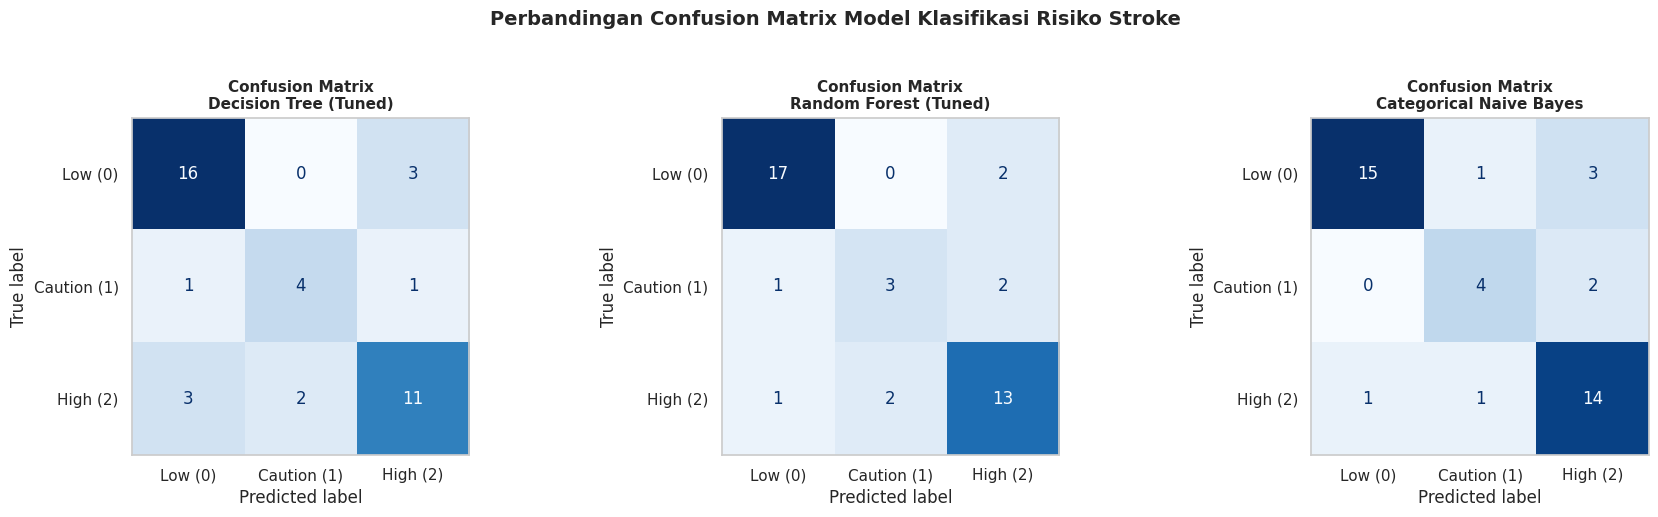

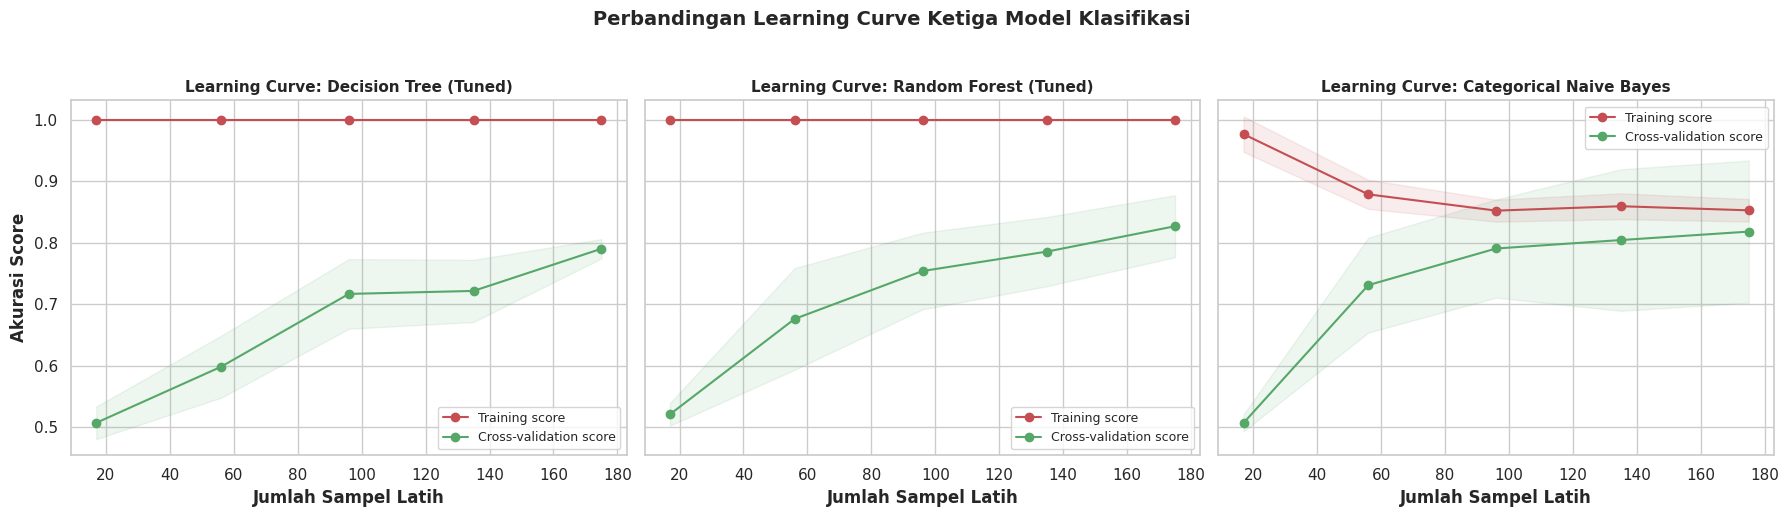

In [11]:
# ===============================================================
# BLOK 3: VISUALISASI CONFUSION MATRIX, LEARNING CURVE (3 MODEL)
# ===============================================================

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import learning_curve

# Mengatur tema visualisasi agar konsisten
sns.set_theme(style='whitegrid')

# ------------------------------------------------------------------------------
# 1. VISUALISASI CONFUSION MATRIX (HEATMAP) UNTUK KETIGA MODEL
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_to_plot = [
    ('Decision Tree (Tuned)', best_dt, y_pred_dt),
    ('Random Forest (Tuned)', best_rf, y_pred_rf),
    ('Categorical Naive Bayes', best_nb, y_pred_nb),
]

for idx, (name, model, y_pred) in enumerate(models_to_plot):
  cm = confusion_matrix(y_test, y_pred)
  disp = ConfusionMatrixDisplay(
      confusion_matrix=cm, display_labels=['Low (0)', 'Caution (1)', 'High (2)']
  )
  disp.plot(ax=axes[idx], cmap='Blues', colorbar=False, values_format='d')
  axes[idx].set_title(f'Confusion Matrix\n{name}', fontsize=11, fontweight='bold')
  axes[idx].grid(False)

plt.suptitle(
    'Perbandingan Confusion Matrix Model Klasifikasi Risiko Stroke',
    fontsize=14,
    fontweight='bold',
    y=1.03,
)
plt.tight_layout()
plt.savefig('Visualisasi_Confusion_Matrix.png', dpi=300, bbox_inches='tight')
plt.show()


# ------------------------------------------------------------------------------
# 2. VISUALISASI LEARNING CURVE UNTUK KETIGA MODEL (BERDAMPINGAN)
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

models_for_lc = [
    ('Decision Tree (Tuned)', best_dt),
    ('Random Forest (Tuned)', best_rf),
    ('Categorical Naive Bayes', best_nb),
]

for idx, (name, estimator) in enumerate(models_for_lc):
  train_sizes, train_scores, test_scores = learning_curve(
      estimator,
      X_train_res,
      y_train_res,
      cv=cv,
      n_jobs=-1,
      train_sizes=np.linspace(0.1, 1.0, 5),
      scoring='accuracy',
  )

  train_scores_mean = np.mean(train_scores, axis=1)
  train_scores_std = np.std(train_scores, axis=1)
  test_scores_mean = np.mean(test_scores, axis=1)
  test_scores_std = np.std(test_scores, axis=1)

  ax = axes[idx]
  ax.fill_between(
      train_sizes,
      train_scores_mean - train_scores_std,
      train_scores_mean + train_scores_std,
      alpha=0.1,
      color='r',
  )
  ax.fill_between(
      train_sizes,
      test_scores_mean - test_scores_std,
      test_scores_mean + test_scores_std,
      alpha=0.1,
      color='g',
  )
  ax.plot(
      train_sizes, train_scores_mean, 'o-', color='r', label='Training score'
  )
  ax.plot(
      train_sizes,
      test_scores_mean,
      'o-',
      color='g',
      label='Cross-validation score',
  )

  ax.set_title(f'Learning Curve: {name}', fontsize=11, fontweight='bold')
  ax.set_xlabel('Jumlah Sampel Latih', fontweight='bold')
  if idx == 0:
    ax.set_ylabel('Akurasi Score', fontweight='bold')
  ax.legend(loc='best', fontsize=9)
  ax.grid(True)

plt.suptitle(
    'Perbandingan Learning Curve Ketiga Model Klasifikasi',
    fontsize=14,
    fontweight='bold',
    y=1.03,
)
plt.tight_layout()
plt.savefig('Visualisasi_Learning_Curve_All.png', dpi=300, bbox_inches='tight')
plt.show()
